##Prashna Prajapati
##Worksheet_5

#Task 1: Data Understanding and Visualization:

##1. Load and visualize images from a dataset stored in directories, where each subdirectory represents a class.

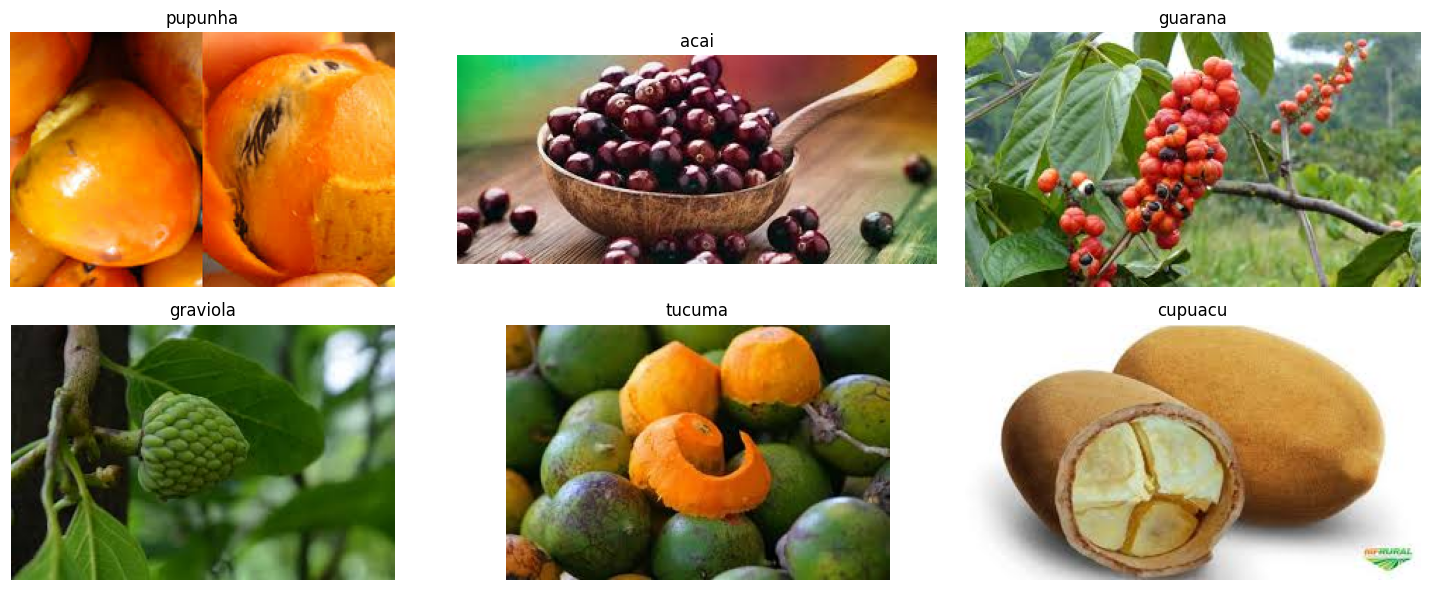

In [13]:
import os
import random
import matplotlib.pyplot as plt
from PIL import Image

train_dir = "/content/drive/MyDrive/Dataset/FruitinAmazon/train"

classes = [cls for cls in os.listdir(train_dir)
           if os.path.isdir(os.path.join(train_dir, cls))]

images = []
labels = []

for cls in classes:
    cls_path = os.path.join(train_dir, cls)
    img_files = os.listdir(cls_path)

    if len(img_files) == 0:
        continue

    img_name = random.choice(img_files)
    img_path = os.path.join(cls_path, img_name)

    try:
        img = Image.open(img_path)
        images.append(img)
        labels.append(cls)
    except:
        print(f"Error loading image: {img_path}")

num_images = len(images)
cols = (num_images + 1) // 2

plt.figure(figsize=(15, 6))

for i in range(num_images):
    plt.subplot(2, cols, i + 1)
    plt.imshow(images[i])
    plt.title(labels[i])
    plt.axis("off")

plt.tight_layout()
plt.show()

##• What did you Observe?

###Observation:

###Images belong to different fruit classes

###Variations in color, shape, background

###Some classes may look visually similar → harder classification

##2. Check for Corrupted Image:

In [14]:
from PIL import Image
import os

corrupted = []

for cls in os.listdir(train_dir):
    cls_path = os.path.join(train_dir, cls)

    if not os.path.isdir(cls_path):
        continue

    for img_name in os.listdir(cls_path):
        img_path = os.path.join(cls_path, img_name)

        try:
            with Image.open(img_path) as img:
                img.verify()
        except (IOError, SyntaxError, OSError):
            corrupted.append(img_path)
            os.remove(img_path)
            print(f"Removed corrupted image: {img_path}")

if len(corrupted) == 0:
    print("No Corrupted Images Found.")
else:
    print(f"Total corrupted images removed: {len(corrupted)}")

No Corrupted Images Found.


#Task2 : Loading and Preprocessing Image Data in Keras:

In [15]:
import tensorflow as tf

train_dir = "/content/drive/MyDrive/Dataset/FruitinAmazon/train"

img_height = 128
img_width = 128
batch_size = 16
validation_split = 0.2
seed = 123

rescale = tf.keras.layers.Rescaling(1./255)

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    batch_size=batch_size,
    shuffle=True,
    validation_split=validation_split,
    subset='training',
    seed=seed
)

class_names = train_ds.class_names
num_classes = len(class_names)

train_ds = train_ds.map(lambda x, y: (rescale(x), y))

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    batch_size=batch_size,
    shuffle=False,
    validation_split=validation_split,
    subset='validation',
    seed=seed
)

val_ds = val_ds.map(lambda x, y: (rescale(x), y))

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)

Found 90 files belonging to 6 classes.
Using 72 files for training.
Found 90 files belonging to 6 classes.
Using 18 files for validation.


#Task 3 - Implement a CNN with

In [16]:
from tensorflow.keras import layers, models

model = models.Sequential([
    layers.Conv2D(32, (3,3), padding='same', activation='relu',
                  input_shape=(img_height, img_width, 3)),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(32, (3,3), padding='same', activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),

    layers.Dense(64, activation='relu'),
    layers.Dense(128, activation='relu'),

    layers.Dense(num_classes, activation='softmax')
])

#Task 4: Compile the Model

In [17]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │     2,097,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,116,454 (8.07 MB)

 Trainable params: 2,116,454 (8.07 MB)

 Non-trainable params: 0 (0.00 B)

#Task 4: Train the Model

##Model Training

In [18]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

checkpoint_cb = ModelCheckpoint(
    "best_model.h5",
    save_best_only=True,
    monitor="val_accuracy",
    mode="max",
    verbose=1
)

earlystop_cb = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True,
    verbose=1
)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=250,
    callbacks=[checkpoint_cb, earlystop_cb]
)

Epoch 1/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 254ms/step - accuracy: 0.0993 - loss: 1.7927
Epoch 1: val_accuracy improved from None to 0.16667, saving model to best_model.h5



Epoch 1: finished saving model to best_model.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 427ms/step - accuracy: 0.1528 - loss: 1.7942 - val_accuracy: 0.1667 - val_loss: 1.8700
Epoch 2/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 457ms/step - accuracy: 0.5795 - loss: 1.4219
Epoch 2: val_accuracy improved from 0.16667 to 0.66667, saving model to best_model.h5



Epoch 2: finished saving model to best_model.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 566ms/step - accuracy: 0.4861 - loss: 1.4220 - val_accuracy: 0.6667 - val_loss: 1.1533
Epoch 3/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 316ms/step - accuracy: 0.5128 - loss: 1.1097
Epoch 3: val_accuracy did not improve from 0.66667
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 367ms/step - accuracy: 0.5278 - loss: 1.0249 - val_accuracy: 0.6111 - val_loss: 1.2415
Epoch 4/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 276ms/step - accuracy: 0.8264 - loss: 0.7920
Epoch 4: val_accuracy improved from 0.66667 to 0.88889, saving model to best_model.h5



Epoch 4: finished saving model to best_model.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 380ms/step - accuracy: 0.8194 - loss: 0.7288 - val_accuracy: 0.8889 - val_loss: 0.4196
Epoch 5/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 278ms/step - accuracy: 0.8576 - loss: 0.4859
Epoch 5: val_accuracy did not improve from 0.88889
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 328ms/step - accuracy: 0.8611 - loss: 0.4547 - val_accuracy: 0.3333 - val_loss: 1.3438
Epoch 6/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 279ms/step - accuracy: 0.8653 - loss: 0.3655
Epoch 6: val_accuracy did not improve from 0.88889
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 335ms/step - accuracy: 0.8889 - loss: 0.3371 - val_accuracy: 0.8889 - val_loss: 0.3056
Epoch 7/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 277ms/step - accuracy: 0.9448 - loss: 0.1912
Epoch 7: val_accuracy did not improve from 0.88889
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 330ms/step - accuracy: 0.9167 - loss: 0.2177 - val_accuracy: 0.8333 - val_loss: 0.3861
Epoch 8/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 334ms/step - accuracy: 0.9840 - loss: 0.112

#Task 5: Evaluate the Model
##Model Evaluation

In [19]:
test_dir = "/content/drive/MyDrive/Dataset/FruitinAmazon/test"

test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    test_dir,
    image_size=(img_height, img_width),
    batch_size=batch_size,
    shuffle=False
)

test_ds = test_ds.map(lambda x, y: (rescale(x), y))
test_ds = test_ds.prefetch(buffer_size=tf.data.AUTOTUNE)

test_loss, test_acc = model.evaluate(test_ds)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_acc)

Found 30 files belonging to 6 classes.
2/2 ━━━━━━━━━━━━━━━━━━━━ 5s 2s/step - accuracy: 0.8000 - loss: 0.9729
Test Loss: 0.97288578748703
Test Accuracy: 0.800000011920929


#Task 6: Save and Load the Model
##Model Saving and Loading

In [20]:
# Save
model.save("cnn_model.h5")

# Load
from tensorflow.keras.models import load_model
loaded_model = load_model("cnn_model.h5")

# Re-evaluate
loaded_model.evaluate(test_ds)

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 82ms/step - accuracy: 0.8000 - loss: 0.9729


[0.97288578748703, 0.800000011920929]

#Task 7: Predictions and Classification Report
##Making Predictions

In [21]:
import numpy as np
from sklearn.metrics import classification_report

y_true = []
y_pred = []

for images, labels in test_ds:
    preds = model.predict(images)
    preds = np.argmax(preds, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(preds)

print("\nClassification Report:\n")
print(classification_report(y_true, y_pred, target_names=class_names))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 180ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 162ms/step

Classification Report:

              precision    recall  f1-score   support

        acai       1.00      0.80      0.89         5
     cupuacu       0.57      0.80      0.67         5
    graviola       0.62      1.00      0.77         5
     guarana       1.00      0.80      0.89         5
     pupunha       1.00      1.00      1.00         5
      tucuma       1.00      0.40      0.57         5

    accuracy                           0.80        30
   macro avg       0.87      0.80      0.80        30
weighted avg       0.87      0.80      0.80        30



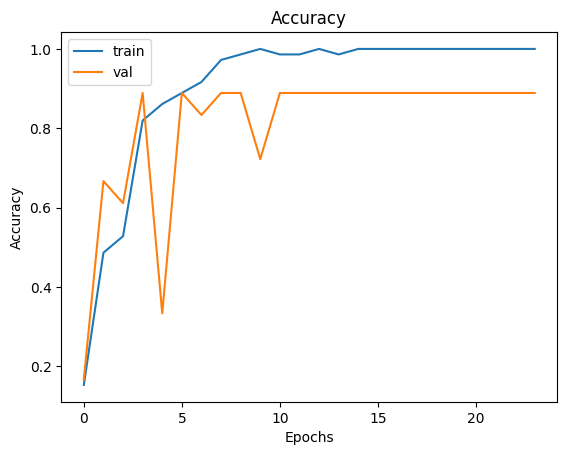

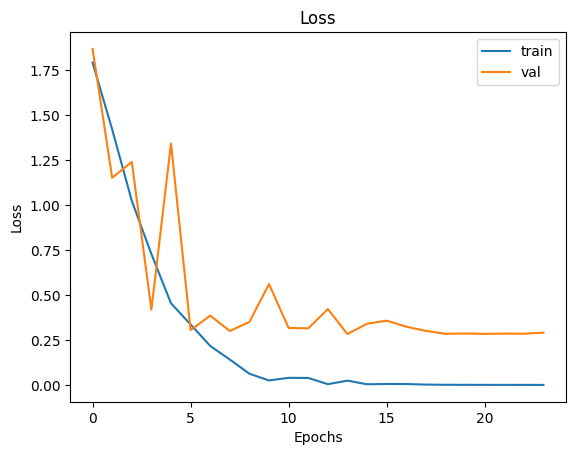

In [22]:
import matplotlib.pyplot as plt

# Accuracy
plt.figure()
plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='val')
plt.title('Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# Loss
plt.figure()
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.title('Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()